# Carousel Lens — gigalens Model

Single-band (HST WFC3/IR F140W), single-source strong lens model.  
Mass: EPL + external shear  
Source: SersicShapelets  

Reference: Urcelay et al. 2026 (arXiv:2602.16077)

## 1. Imports

In [10]:
import sys
sys.path.insert(0, '../sean-carousel/src')

import numpy as np
import json
import optax
import jax
import jax.numpy as jnp
from astropy.io import fits
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import BackwardProbModel
from gigalens.jax.physical_model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles import mass, light
from gigalens.jax.profiles.light import sersic_shapelets as ss_mod
from gigalens.jax.prior import Prior, make_prior_and_model

tfd = tfp.distributions
plt.rcParams['figure.dpi'] = 150
print('Imports OK | devices:', jax.devices())

Imports OK | devices: [CudaDevice(id=0)]


## 2. Load Data

In [11]:
# Use the existing processed HST F140W image (program GO-16773)
F140W_PATH = "../sean-carousel/model_data/f140w_img.fits"

with fits.open(F140W_PATH) as hdul:
    obs_native = hdul[0].data.astype(np.float32)
    hdr = hdul[0].header
    exp_time = float(hdr["EXPTIME"])
    bkg_rms  = float(hdr["BKGRMS"])

# Bin 2x2: 800x800 -> 400x400.  Reduces GPU memory ~8x (float32 + half the pixels).
# At 0.0698"/px native, binned scale = 0.1396"/px; FoV unchanged at ~55.9".
BIN = 2
h, w = obs_native.shape
obs = obs_native[:h//BIN*BIN, :w//BIN*BIN].reshape(h//BIN, BIN, w//BIN, BIN).mean(axis=(1, 3))

# Pixel scale from WCS PC matrix, adjusted for binning
pc = np.array([[hdr["PC1_1"], hdr["PC1_2"]],
               [hdr["PC2_1"], hdr["PC2_2"]]])
delta_pix = np.sqrt(np.sum(pc[0]**2)) * 3600 * BIN   # arcsec/pixel
num_pix   = obs.shape[0]

# Scale background rms: mean of BIN^2 pixels -> rms / sqrt(BIN^2)
bkg_rms_binned = bkg_rms / BIN

print(f"Native image : {obs_native.shape}, delta_pix={hdr["BKGRMS"]:.5f}")
print(f"Binned image : {obs.shape}  delta_pix={delta_pix:.5f} arcsec/px")
print(f"FoV          : {num_pix * delta_pix:.2f}" )
print(f"exp_time     : {exp_time} s")
print(f"bkg_rms      : {bkg_rms_binned:.6f}  (binned)")
bkg_rms = bkg_rms_binned


Native image : (800, 800), delta_pix=0.00696
Binned image : (400, 400)  delta_pix=0.13966 arcsec/px
FoV          : 55.86
exp_time     : 597.694383 s
bkg_rms      : 0.003479  (binned)


PSF shape: (27, 27), sum: 1.000000


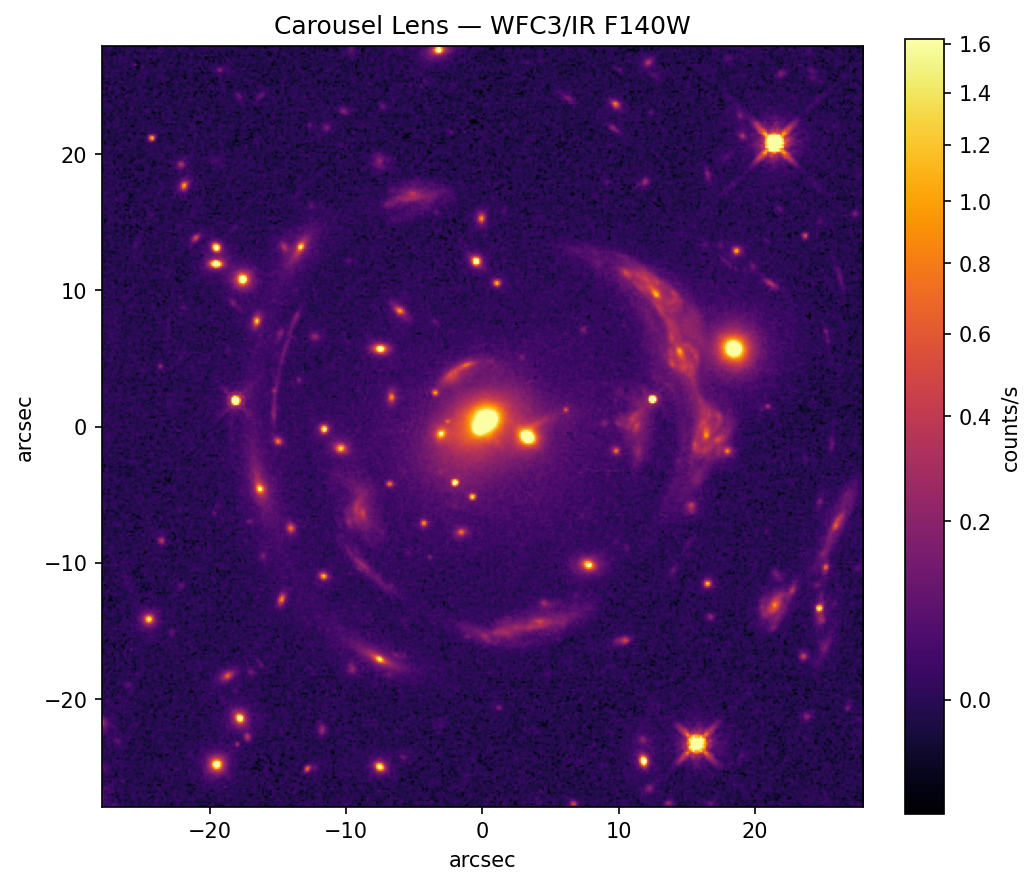

In [12]:
# PSF — from carousel-lens directory (27x27, normalized)
kernel = np.load('../carousel-lens/psf.npy').astype(np.float64)
kernel /= kernel.sum()
print(f'PSF shape: {kernel.shape}, sum: {kernel.sum():.6f}')

extent = (
    -num_pix/2 * delta_pix, num_pix/2 * delta_pix,
    -num_pix/2 * delta_pix, num_pix/2 * delta_pix,
)

norm = simple_norm(obs, 'sqrt', percent=99.5)
plt.figure(figsize=(7, 7))
plt.imshow(obs, norm=norm, origin='lower', cmap='inferno', extent=extent)
plt.xlabel('arcsec')
plt.ylabel('arcsec')
plt.title('Carousel Lens — WFC3/IR F140W')
plt.colorbar(label='counts/s', fraction=0.046)
plt.tight_layout()
plt.show()

## 3. Priors

Mass: EPL + external shear  
Source: SersicShapelets (order 6)  

Coordinate origin = image center. Positions in arcsec.  
Main halo center informed by MAP result from `sean-carousel`.

In [ ]:
# Deflection ratios Dls/Ds for z_l=0.49, FlatLCDM(H0=70, Om0=0.3)
dr_0962 = 0.4219   # S1  (z_s=0.962)
dr_1166 = 0.4969   # S3  (z_s=1.166, naked cusp)
dr_1432 = 0.5619   # S4, S5  (z_s=1.432)
dr_4520 = 0.7527   # S7  (z_s=4.52)

# Priors from Sheu et al. 2024 Table 2 (lenstronomy fit on HST F140W).
# Ellipticity: c = (1-q)/(1+q), phi = PA.  e1 = c*cos(2φ), e2 = c*sin(2φ)
#   La:  q=0.87, PA=-45° → c=0.069 → e1= 0.000, e2=-0.069
#   Ld:  q=0.69, PA=-38° → c=0.183 → e1=+0.044, e2=-0.178
# Shear: γ_ext=0.11, φ=9° → γ1=γcos(2φ)=0.105, γ2=γsin(2φ)=0.034

# --- La: EPL  θ_E=13.03", γ=1.67, q=0.87, PA=-45° ---
la_prior = Prior(
    mass.epl.EPL(),
    dict(
        center_x = tfd.Normal(6.70, 0.5),
        center_y = tfd.Normal(4.80, 0.5),
        e1       = tfd.TruncatedNormal( 0.000, 0.05, -0.3, 0.3),
        e2       = tfd.TruncatedNormal(-0.069, 0.05, -0.3, 0.3),
        theta_E  = tfd.Normal(13.03, 0.5),
        gamma    = tfd.TruncatedNormal(1.67, 0.08, 1.5, 2.5),
    )
)

# --- Ld: EPL  θ_E=0.99", γ=2.12, q=0.69, PA=-38° (Table 2 — EPL, NOT DPIE) ---
# Position from Sean's MUSE MAP (not tabulated in paper)
ld_prior = Prior(
    mass.epl.EPL(),
    dict(
        center_x = tfd.Normal(11.81, 1.0),
        center_y = tfd.Normal(23.03, 1.0),
        e1       = tfd.TruncatedNormal( 0.044, 0.05, -0.3, 0.3),
        e2       = tfd.TruncatedNormal(-0.178, 0.05, -0.3, 0.3),
        theta_E  = tfd.Normal(0.99, 0.15),
        gamma    = tfd.TruncatedNormal(2.12, 0.10, 1.5, 2.5),
    )
)

# --- External shear  γ_ext=0.11, φ=9° ---
shear_prior = Prior(
    mass.shear.Shear(),
    dict(
        gamma1 = tfd.Normal(0.105, 0.05),
        gamma2 = tfd.Normal(0.034, 0.05),
    )
)

# --- BCG foreground ---
bcg_prior = Prior(
    light.sersic.SersicEllipse(use_lstsq=True),
    dict(
        center_x = tfd.Normal(6.70, 0.3),
        center_y = tfd.Normal(4.80, 0.3),
        e1       = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        e2       = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        n_sersic = tfd.Uniform(2., 8.),
        R_sersic = tfd.LogNormal(jnp.log(3.0), 0.3),
    )
)

# --- Sources: positions from Sean's MAP (boiler.py) ---
# n_max=6 (depth=28) for bright/complex arcs; n_max=4 (depth=15) for fainter ones
def _src(dr, cx, cy, n_max=6, sig=1.5):
    return Prior(
        ss_mod.SersicShapelets(n_max=n_max, use_lstsq=True, cosmo_sample=False),
        dict(
            deflection_ratio = dr,
            center_x  = tfd.Normal(cx, sig),
            center_y  = tfd.Normal(cy, sig),
            e1        = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
            e2        = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
            n_sersic  = tfd.Uniform(0.5, 6.),
            R_sersic  = tfd.LogNormal(jnp.log(0.4), 0.3),
            beta      = tfd.LogNormal(jnp.log(0.4), 0.3),
        )
    )

src1_prior = _src(dr_0962, 7.67, 3.32, n_max=6)   # S1  z=0.962
src3_prior = _src(dr_1166, 6.80, 7.92, n_max=6)   # S3  z=1.166, naked cusp
src4_prior = _src(dr_1432, 4.63, 3.79, n_max=6)   # S4  z=1.432, Einstein cross
src5_prior = _src(dr_1432, 4.78, 0.84, n_max=4)   # S5  z=1.432, fold quad
src7_prior = _src(dr_4520, 6.70, 4.80, n_max=4)   # S7  z=4.52

prior, phys_model = make_prior_and_model(
    lenses     = [la_prior, ld_prior, shear_prior],
    sources    = [src1_prior, src3_prior, src4_prior, src5_prior, src7_prior],
    foreground = [bcg_prior],
)
print("Prior created — from Sheu+2024 Table 2")
print(f"  La: θ_E~13.03\", γ~1.67 | Ld (EPL): θ_E~0.99\", γ~2.12 | γ_ext~0.11")

## 4. Simulator + Probabilistic Model

In [14]:
sim_config = SimulatorConfig(
    delta_pix   = delta_pix,
    num_pix     = num_pix,
    supersample = 1,
    kernel      = kernel,
)

# Circular mask: only fit pixels within 20" of the lens center.
# Cuts ~75% of pixels that are background stars/galaxies the model won't fit,
# so gradients focus entirely on the ring and chi-sq is computed over the arc region.
cx_px = num_pix / 2 + 6.70 / delta_pix
cy_px = num_pix / 2 + 4.80 / delta_pix
yy, xx = np.mgrid[:num_pix, :num_pix]
r_arcsec = np.sqrt((xx - cx_px)**2 + (yy - cy_px)**2) * delta_pix
circ_mask = r_arcsec < 20.0

prob_model = BackwardProbModel(
    prior,
    obs,
    background_rms = bkg_rms,
    exp_time       = exp_time,
    mask           = circ_mask,
)

model_seq = ModellingSequence(phys_model, prob_model, sim_config)
print(f'Mask: {int(circ_mask.sum())} / {num_pix**2} pixels  ({100*circ_mask.mean():.1f}%)')
print('ModellingSequence ready.')

Mask: 64417 / 160000 pixels  (40.3%)
ModellingSequence ready.


## 5. MAP Optimization

In [ ]:
NUM_STEPS  = 5000
N_SAMPLES  = 50

schedule = optax.cosine_decay_schedule(init_value=3e-4, decay_steps=NUM_STEPS, alpha=1e-2)
optimizer = optax.adabelief(schedule, b1=0.95, b2=0.99)

start = prior.sample(N_SAMPLES, jax.random.PRNGKey(0))

print(f"Running MAP: {N_SAMPLES} chains x {NUM_STEPS} steps ...")
best, lps, chisq = model_seq.MAP(
    optimizer  = optimizer,
    n_samples  = N_SAMPLES,
    num_steps  = NUM_STEPS,
    start      = start,
    seed       = 0,
)
print(f"Done. Best reduced chi2 = {float(chisq[-1]):.4f}")

Running MAP: 50 chains x 8000 steps ...


  0%|          | 0/8000 [00:16<?, ?it/s]2026-05-22 14:38:25.362863: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng1{k2=4,k3=0} for conv %cudnn-conv.2 = (f32[50,120,400,400]{3,2,1,0}, u8[0]{0}) custom-call(%select.11419, %constant.19721), window={size=27x27 pad=13_13x13_13}, dim_labels=bf01_oi01->bf01, feature_group_count=120, custom_call_target="__cudnn$convForward", metadata={op_name="jit(run_map)/jit(main)/while/body/jit(loss)/jvp(jit(log_prob))/jit(log_like)/jit(stats_pixels)/jit(lstsq_simulate)/conv_general_dilated" source_file="/global/u1/c/chaseg/carousel-gigalens/../sean-carousel/src/gigalens/jax/simulator.py" source_line=265}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-05-22 14:39:03.606768: E external/xla/xla/service/slow_op

## 6. Visualize MAP Result

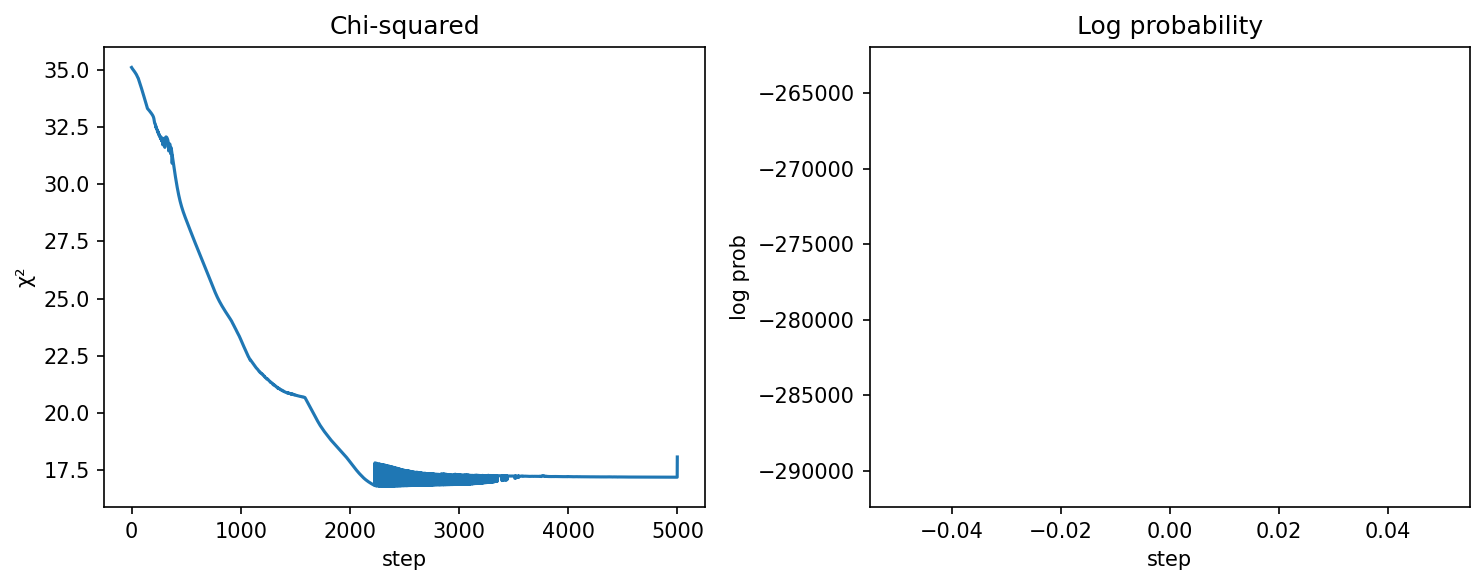

In [ ]:
# Convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(chisq)
ax1.set(xlabel='step', ylabel='χ²', title='Chi-squared')
ax2.plot(lps)
ax2.set(xlabel='step', ylabel='log prob', title='Log probability')
plt.tight_layout()
plt.show()

2026-05-22 14:14:22.162926: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{} for conv %cudnn-conv.1 = (f32[1,7,400,400]{3,2,1,0}, u8[0]{0}) custom-call(%select.20, %constant.74), window={size=27x27 pad=13_13x13_13}, dim_labels=bf01_oi01->bf01, feature_group_count=7, custom_call_target="__cudnn$convForward", metadata={op_name="jit(lstsq_simulate)/jit(main)/conv_general_dilated" source_file="/global/u1/c/chaseg/carousel-gigalens/../sean-carousel/src/gigalens/jax/simulator.py" source_line=265}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-05-22 14:14:22.211695: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investiga

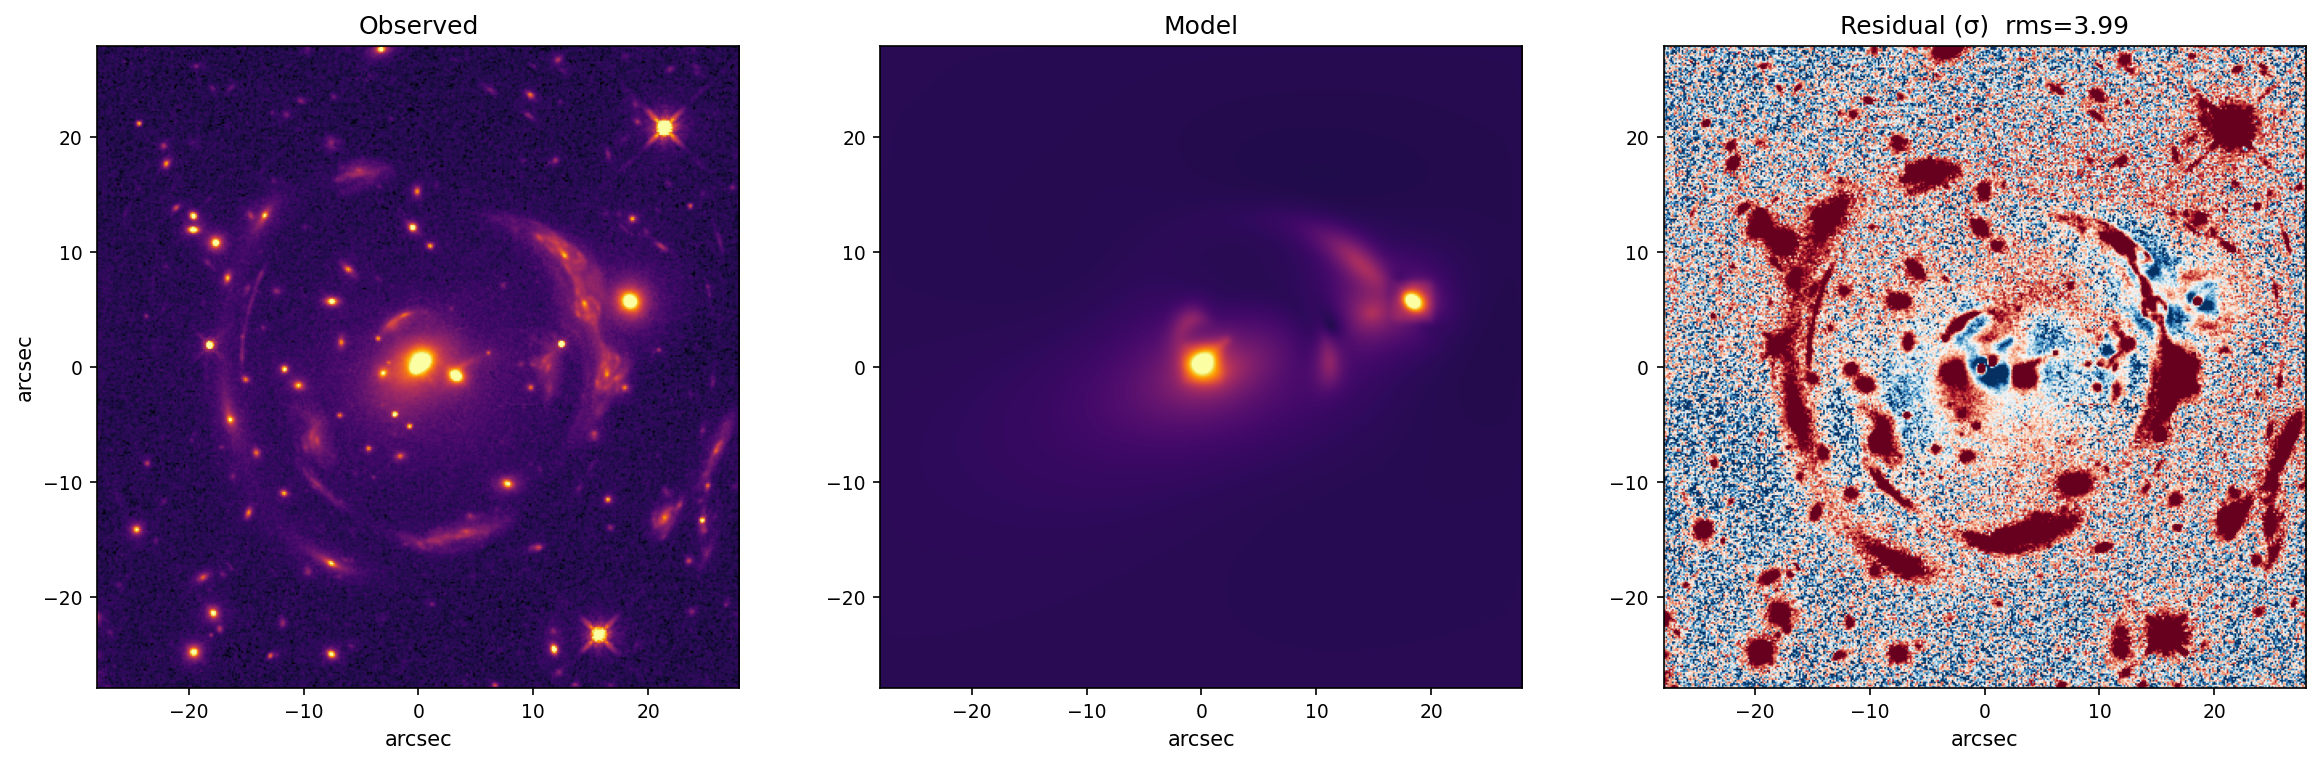

In [ ]:
# Simulate from best-fit parameters
# bij.forward expects list(z.T) — a list of per-parameter (batch,) arrays
simulator = LensSimulator(phys_model, sim_config, bs=1)
best_params = prob_model.bij.forward(list(best.T))   # best shape (1, n_params)

err_map = np.array(prob_model.error_map)
mask    = np.array(prob_model.mask)
sim_im  = np.array(prob_model.simulate(simulator, best_params))  # (H,W) after lstsq squeeze

residual = (obs - sim_im) / err_map

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
n = simple_norm(obs, 'sqrt', percent=99.5)

axes[0].imshow(obs,      norm=n, origin='lower', cmap='inferno', extent=extent)
axes[0].set(title='Observed', xlabel='arcsec', ylabel='arcsec')

axes[1].imshow(sim_im,   norm=n, origin='lower', cmap='inferno', extent=extent)
axes[1].set(title='Model',    xlabel='arcsec')

axes[2].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-5, vmax=5, extent=extent)
axes[2].set(title=f'Residual (σ)  rms={np.nanstd(residual[mask]):.2f}', xlabel='arcsec')

for ax in axes:
    ax.tick_params(labelsize=9)
plt.tight_layout()
import os; os.makedirs('models', exist_ok=True)
plt.savefig('models/MAP_result.png', dpi=150)
plt.show()


## 7. Save Results

In [ ]:
import os
os.makedirs('models', exist_ok=True)

np.save('models/MAP_best.npy', np.array(best))
np.save('models/MAP_chisq.npy', np.array(chisq))
np.save('models/MAP_lps.npy', np.array(lps))

best_phys = prob_model.bij.forward(list(best.T))
print('Best-fit parameters:')
for section, vals in best_phys.items():
    for comp, params in vals.items():
        print(f'  [{section}/{comp}]')
        if isinstance(params, dict):
            for k, v in params.items():
                try:
                    print(f'    {k}: {float(np.array(v).ravel()[0]):.5f}')
                except Exception:
                    print(f'    {k}: {v}')

print('Saved to models/')

Best-fit parameters:
  [source_light/5]
    n_sersic: 1.66363
    e2: -0.12836
    e1: 0.00965
    center_y: 5.47189
    center_x: 6.10814
    R_sersic: 0.39423
  [source_light/4]
    n_sersic: 0.57783
    e2: -0.29204
    e1: -0.28750
    center_y: 2.55695
    center_x: 4.69045
    R_sersic: 0.44012
  [source_light/3]
    n_sersic: 0.50707
    e2: -0.28750
    e1: -0.12597
    center_y: 4.24450
    center_x: 3.87666
    R_sersic: 4.73203
  [source_light/2]
    n_sersic: 1.82068
    e2: 0.25593
    e1: 0.09297
    center_y: 4.57922
    center_x: 7.94089
    R_sersic: 4.39344
  [source_light/1]
    n_sersic: 0.86863
    e2: -0.25024
    e1: 0.00622
    center_y: 5.58125
    center_x: 11.31060
    R_sersic: 0.70427
  [source_light/0]
    n_sersic: 1.75711
    e2: 0.16619
    e1: 0.15605
    center_y: 3.48163
    center_x: 6.40383
    R_sersic: 17.54567
  [lens_mass/2]
    gamma2: -0.02132
    gamma1: 0.22555
  [lens_mass/1]
    theta_E: 0.89293
    gamma: 1.69189
    e2: 0.25193
    e1: 

## 8. Next Steps

Once MAP converges:
1. **SVI** — Gaussian surrogate posterior around the MAP
2. **HMC/NUTS** — full posterior sampling
3. **Expand model** — add second lens component (galaxy-scale perturber), additional sources

See `sean-carousel/carouselSVI.py` and `carouselHMC.py` for templates.